## Question 1

In [ ]:
# Inputs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Maturités du problème
maturities = np.array([0.5, 1, 2, 3, 4, 5, 7, 10, 15, 20, 30], dtype=float)

# Rendements AA donnés dans l'énoncé (en %)
aa_yields = np.array([3.76, 3.79, 3.86, 3.96, 4.08, 4.20, 4.52, 4.83, 5.42, 5.69, 6.01], dtype=float)

# Paramètres Nelson-Siegel-Svensson de la Fed au 27-02-2026
beta0 = 1.61524750808686
beta1 = 2.17223429702024
beta2 = -4.23501121528157e-07
beta3 = 10.4758895855166
tau1  = 1.45929275154091
tau2  = 16.868433782271

In [ ]:
# Fonction zcy(t)

def zcy_svensson(t, beta0, beta1, beta2, beta3, tau1, tau2):
    """
    Rendement zéro coupon en % (capitalisation continue),
    selon la formule Nelson-Siegel-Svensson de la Fed.
    """
    t = np.asarray(t, dtype=float)

    term1 = (1 - np.exp(-t / tau1)) / (t / tau1)
    term2 = term1 - np.exp(-t / tau1)
    term3 = (1 - np.exp(-t / tau2)) / (t / tau2) - np.exp(-t / tau2)

    return beta0 + beta1 * term1 + beta2 * term2 + beta3 * term3

In [ ]:
# Calcul des taux sans risque et des écarts de crédit

rf_zcy = zcy_svensson(maturities, beta0, beta1, beta2, beta3, tau1, tau2)

# Écart de crédit en points de pourcentage
credit_spread = aa_yields - rf_zcy

# Écart de crédit en points de base
credit_spread_bps = 100 * credit_spread

results = pd.DataFrame({
    "Maturité (années)": maturities,
    "AA (%)": aa_yields,
    "zcy sans risque (%)": rf_zcy,
    "Écart de crédit (%)": credit_spread,
    "Écart de crédit (bps)": credit_spread_bps
})

results = results.round({
    "Maturité (années)": 1,
    "AA (%)": 3,
    "zcy sans risque (%)": 3,
    "Écart de crédit (%)": 3,
    "Écart de crédit (bps)": 1
})

print(results.to_string(index=False))

 Maturité (années)  AA (%)  zcy sans risque (%)  Écart de crédit (%)  Écart de crédit (bps)
               0.5    3.76                3.607                0.153                   15.3
               1.0    3.79                3.486                0.304                   30.4
               2.0    3.86                3.372                0.488                   48.8
               3.0    3.96                3.365                0.595                   59.5
               4.0    4.08                3.419                0.661                   66.1
               5.0    4.20                3.506                0.694                   69.4
               7.0    4.52                3.721                0.799                   79.9
              10.0    4.83                4.044                0.786                   78.6
              15.0    5.42                4.461                0.959                   95.9
              20.0    5.69                4.709                0.981            

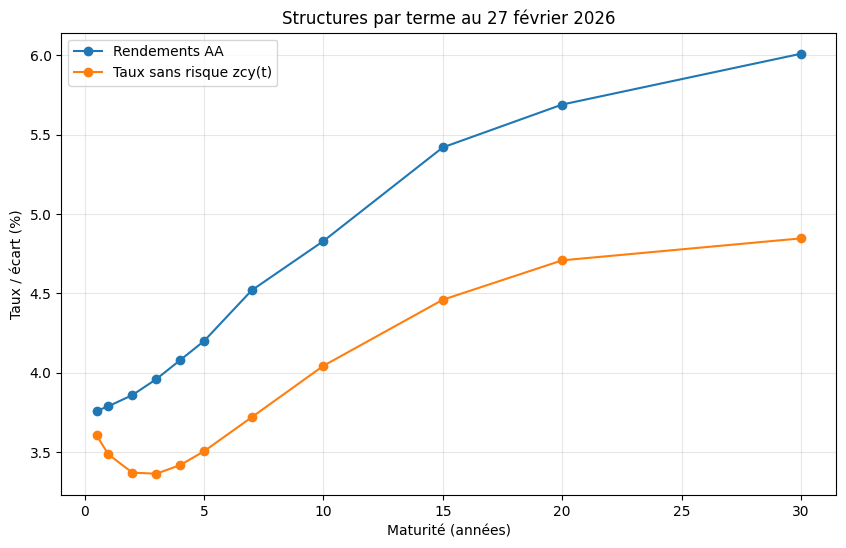

In [ ]:
# Graphique des 3 structures par terme
plt.figure(figsize=(10, 6))
plt.plot(maturities, aa_yields, marker='o', label="Rendements AA")
plt.plot(maturities, rf_zcy, marker='o', label="Taux sans risque zcy(t)")

plt.title("Structures par terme au 27 février 2026")
plt.xlabel("Maturité (années)")
plt.ylabel("Taux / écart (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### La courbe AA est au-dessus de la courbe sans risque pour toutes les maturités, ce qui est cohérent avec la présence d’un risque de crédit positif. Les écarts de crédit augmentent globalement avec la maturité, passant d’environ 15 pb à 6 mois à plus de 116 pb à 30 ans. Cela suggère que le marché exige une prime de risque plus élevée pour détenir des obligations corporatives AA à plus long terme.

## Question 2

In [63]:
# Paramètres
# Maturités
maturities = np.array([0.5, 1, 2, 3, 4, 5, 7, 10, 15, 20, 30], dtype=float)

# Paramètres Duffee / CIR
alpha = 0.0020   # constante dans lambda_t
beta  = 0.30     # sensibilité de lambda_t à r_t

# Paramètres du taux sans risque r_t
kappa_r = 0.50
theta_r = 0.04
sigma_r = 0.10
r0 = 0.035

# Paramètres du facteur s_t
kappa_s = 0.70
theta_s = 0.01
sigma_s = 0.08
s0 = 0.005

In [64]:
# Fonction CIR  
def cir_gamma(kappa, sigma):
    return np.sqrt(kappa**2 + 2 * sigma**2)

def cir_B(t, kappa, sigma):
    gamma = cir_gamma(kappa, sigma)
    num = 2 * (np.exp(gamma * t) - 1)
    den = (gamma + kappa) * (np.exp(gamma * t) - 1) + 2 * gamma
    return num / den

def cir_A(t, kappa, theta, sigma):
    gamma = cir_gamma(kappa, sigma)
    num = 2 * gamma * np.exp((kappa + gamma) * t / 2)
    den = (gamma + kappa) * (np.exp(gamma * t) - 1) + 2 * gamma
    power = 2 * kappa * theta / sigma**2
    return (num / den) ** power

In [65]:
# Prix zéro-coupon CIR
def cir_zero_coupon_price(t, r0, kappa, theta, sigma):
    A = cir_A(t, kappa, theta, sigma)
    B = cir_B(t, kappa, sigma)
    return A * np.exp(-B * r0)

In [66]:
# Prix risqué Duffee et rendement 

def risky_zero_coupon_price_duffee(t, alpha, beta,
                                   r0, kappa_r, theta_r, sigma_r,
                                   s0, kappa_s, theta_s, sigma_s):
    """
    Prix d'une obligation zéro-coupon risquée dans le modèle de Duffee.
    """

    # Facteur x_t = (1+beta) r_t
    x0 = (1 + beta) * r0
    kappa_x = kappa_r
    theta_x = (1 + beta) * theta_r
    sigma_x = np.sqrt(1 + beta) * sigma_r

    # Prix CIR du facteur x
    Px = cir_zero_coupon_price(t, x0, kappa_x, theta_x, sigma_x)

    # Prix CIR du facteur s
    Ps = cir_zero_coupon_price(t, s0, kappa_s, theta_s, sigma_s)

    # Prix risqué
    P_risky = np.exp(-alpha * t) * Px * Ps
    return P_risky


def risky_yield_duffee(t, alpha, beta,
                       r0, kappa_r, theta_r, sigma_r,
                       s0, kappa_s, theta_s, sigma_s):
    """
    Rendement zéro-coupon risqué Y(t), en taux continu.
    """
    P = risky_zero_coupon_price_duffee(
        t, alpha, beta,
        r0, kappa_r, theta_r, sigma_r,
        s0, kappa_s, theta_s, sigma_s
    )
    return -np.log(P) / t

In [67]:
# Calcul aux 11 maturités
risky_yields = np.array([
    risky_yield_duffee(
        t, alpha, beta,
        r0, kappa_r, theta_r, sigma_r,
        s0, kappa_s, theta_s, sigma_s
    )
    for t in maturities
])

results = pd.DataFrame({
    "Maturité": maturities,
    "Y(t) continu": risky_yields,
    "Y(t) %": 100 * risky_yields
})

print(results.round(4).to_string(index=False))

 Maturité  Y(t) continu  Y(t) %
      0.5        0.0540  5.4008
      1.0        0.0552  5.5215
      2.0        0.0570  5.6985
      3.0        0.0582  5.8181
      4.0        0.0590  5.9018
      5.0        0.0596  5.9621
      7.0        0.0604  6.0410
     10.0        0.0611  6.1062
     15.0        0.0616  6.1588
     20.0        0.0619  6.1853
     30.0        0.0621  6.2119


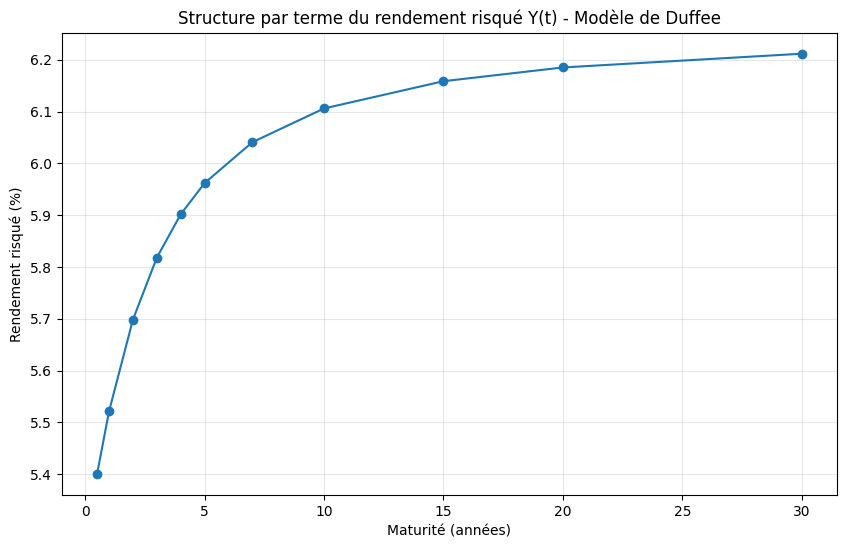

In [68]:
# Graphique de la structure par terme du rendement risqué Y(t)
plt.figure(figsize=(10, 6))
plt.plot(maturities, 100 * risky_yields, marker='o')
plt.title("Structure par terme du rendement risqué Y(t) - Modèle de Duffee")
plt.xlabel("Maturité (années)")
plt.ylabel("Rendement risqué (%)")
plt.grid(True, alpha=0.3)
plt.show()

## Question 3

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

### Données

In [70]:
# Maturités
maturities = np.array([0.5, 1, 2, 3, 4, 5, 7, 10, 15, 20, 30], dtype=float)

# Rendements AA observés (en %, selon l'énoncé)
aa_yields_pct = np.array([3.76, 3.79, 3.86, 3.96, 4.08, 4.20, 4.52, 4.83, 5.42, 5.69, 6.01], dtype=float)

# Conversion en décimal
aa_yields = aa_yields_pct / 100

### Paramètres NSS de la Fed et calcul des zcy(t)

In [71]:
# Paramètres Nelson-Siegel-Svensson de la Fed (27 février 2026)
beta0_nss = 1.61524750808686
beta1_nss = 2.17223429702024
beta2_nss = -4.23501121528157e-07
beta3_nss = 10.4758895855166
tau1_nss  = 1.45929275154091
tau2_nss  = 16.868433782271

def zcy_svensson(t, beta0, beta1, beta2, beta3, tau1, tau2):
    t = np.asarray(t, dtype=float)

    term1 = (1 - np.exp(-t / tau1)) / (t / tau1)
    term2 = term1 - np.exp(-t / tau1)
    term3 = (1 - np.exp(-t / tau2)) / (t / tau2) - np.exp(-t / tau2)

    return beta0 + beta1 * term1 + beta2 * term2 + beta3 * term3

# zcy(t) en % puis en décimal
zcy_pct = zcy_svensson(
    maturities,
    beta0_nss, beta1_nss, beta2_nss, beta3_nss,
    tau1_nss, tau2_nss
)

zcy = zcy_pct / 100

### Fonctions CIR

In [72]:
# Fonctions CIR
def cir_gamma(kappa, sigma):
    return np.sqrt(kappa**2 + 2 * sigma**2)

def cir_B(t, kappa, sigma):
    gamma = cir_gamma(kappa, sigma)
    num = 2 * (np.exp(gamma * t) - 1)
    den = (gamma + kappa) * (np.exp(gamma * t) - 1) + 2 * gamma
    return num / den

def cir_A(t, kappa, theta, sigma):
    gamma = cir_gamma(kappa, sigma)
    num = 2 * gamma * np.exp((kappa + gamma) * t / 2)
    den = (gamma + kappa) * (np.exp(gamma * t) - 1) + 2 * gamma
    power = 2 * kappa * theta / (sigma ** 2)
    return (num / den) ** power

def cir_zero_coupon_price(t, x0, kappa, theta, sigma):
    A = cir_A(t, kappa, theta, sigma)
    B = cir_B(t, kappa, sigma)
    return A * np.exp(-B * x0)

def cir_yield(t, x0, kappa, theta, sigma):
    P = cir_zero_coupon_price(t, x0, kappa, theta, sigma)
    return -np.log(P) / t

### Étape 1 : calibration du sans risque

In [73]:
def objective_risk_free(params, maturities, zcy_obs):
    r0, kappa_r, theta_r, sigma_r = params

    # Contraintes de positivité
    if min(params) <= 0:
        return 1e12

    # Rendements théoriques
    zcy_model = np.array([
        cir_yield(t, r0, kappa_r, theta_r, sigma_r)
        for t in maturities
    ])

    # Erreurs en bps
    errors_bps = 10000 * (zcy_model - zcy_obs)

    # On met un peu plus de poids aux très courtes et très longues maturités
    weights = np.array([1.5, 1.3, 1.1, 1.0, 1.0, 1.0, 1.0, 1.1, 1.2, 1.3, 1.5])

    # Petite pénalité pour éviter sigma ~ 0
    penalty = 0.0
    penalty += 5e4 * max(0.0, 1e-4 - sigma_r)**2

    # Pénalité douce si la condition de Feller est très violée
    feller_gap = sigma_r**2 - 2 * kappa_r * theta_r
    penalty += 1e4 * max(0.0, feller_gap)**2

    return np.sum(weights * errors_bps**2) + penalty

In [74]:
# Bornes
bounds_rf = [
    (0.001, 0.08),   # r0
    (0.01, 5.00),    # kappa_r
    (0.005, 0.12),   # theta_r
    (0.005, 0.30)    # sigma_r
]

# Plusieurs points de départ
initial_guesses_rf = [
    np.array([0.035, 0.50, 0.040, 0.10]),
    np.array([0.030, 0.30, 0.050, 0.05]),
    np.array([0.040, 1.00, 0.045, 0.08]),
    np.array([0.025, 0.20, 0.060, 0.03]),
    np.array([0.035, 2.00, 0.035, 0.12]),
]

best_result_rf = None
best_value_rf = np.inf

for x0_rf in initial_guesses_rf:
    result = minimize(
        objective_risk_free,
        x0=x0_rf,
        args=(maturities, zcy),
        method='L-BFGS-B',
        bounds=bounds_rf
    )

    if result.fun < best_value_rf:
        best_value_rf = result.fun
        best_result_rf = result

result_rf = best_result_rf
r0_hat, kappa_r_hat, theta_r_hat, sigma_r_hat = result_rf.x

print("=== Calibration sans risque ===")
print(f"r0      = {r0_hat:.6f}")
print(f"kappa_r = {kappa_r_hat:.6f}")
print(f"theta_r = {theta_r_hat:.6f}")
print(f"sigma_r = {sigma_r_hat:.6f}")
print(f"Objective = {result_rf.fun:.4f}")
print(f"Success   = {result_rf.success}")
print(f"Message   = {result_rf.message}")

=== Calibration sans risque ===
r0      = 0.033120
kappa_r = 0.018583
theta_r = 0.120000
sigma_r = 0.031354
Objective = 3136.7153
Success   = True
Message   = CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


### Rendements sans risque calibrés

In [75]:
zcy_fit = np.array([
    cir_yield(t, r0_hat, kappa_r_hat, theta_r_hat, sigma_r_hat)
    for t in maturities
])

rf_table = pd.DataFrame({
    "Maturité": maturities,
    "zcy observé (%)": 100 * zcy,
    "zcy calibré (%)": 100 * zcy_fit,
    "Erreur (bps)": 10000 * (zcy_fit - zcy)
})

print(rf_table.round(4).to_string(index=False))
rmse_rf_bps = np.sqrt(np.mean((10000 * (zcy_fit - zcy))**2))
print(f"\nRMSE sans risque = {rmse_rf_bps:.2f} bps")

 Maturité  zcy observé (%)  zcy calibré (%)  Erreur (bps)
      0.5           3.6067           3.3521      -25.4518
      1.0           3.4862           3.3917       -9.4448
      2.0           3.3717           3.4694        9.7620
      3.0           3.3648           3.5449       18.0156
      4.0           3.4187           3.6185       19.9770
      5.0           3.5060           3.6901       18.4118
      7.0           3.7207           3.8274       10.6736
     10.0           4.0444           4.0194       -2.4973
     15.0           4.4605           4.3045      -15.6046
     20.0           4.7087           4.5503      -15.8397
     30.0           4.8471           4.9445        9.7448

RMSE sans risque = 15.39 bps


### Fonction du rendement risqué Y(t)

In [76]:
def objective_risky(params, maturities, aa_obs,
                    r0, kappa_r, theta_r, sigma_r):
    s0, kappa_s, theta_s, sigma_s, alpha, beta = params

    if s0 <= 0 or kappa_s <= 0 or theta_s <= 0 or sigma_s <= 0:
        return 1e12

    if beta <= -0.95:
        return 1e12

    y_model = np.array([
        risky_yield_duffee(
            t, alpha, beta,
            r0, kappa_r, theta_r, sigma_r,
            s0, kappa_s, theta_s, sigma_s
        )
        for t in maturities
    ])

    errors_bps = 10000 * (y_model - aa_obs)

    # On force un peu plus le bon fit aux longues maturités
    weights = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.1, 1.2, 1.3, 1.5, 1.6, 1.8])

    penalty = 0.0
    penalty += 5e4 * max(0.0, 1e-4 - sigma_s)**2
    penalty += 5e4 * max(0.0, 1e-4 - theta_s)**2

    feller_gap = sigma_s**2 - 2 * kappa_s * theta_s
    penalty += 1e4 * max(0.0, feller_gap)**2

    return np.sum(weights * errors_bps**2) + penalty

### Étape 2 : calibration sur les rendements AA

In [77]:
def objective_risky(params, maturities, aa_obs,
                    r0, kappa_r, theta_r, sigma_r):
    s0, kappa_s, theta_s, sigma_s, alpha, beta = params

    # Conditions minimales
    if s0 <= 0 or kappa_s <= 0 or theta_s <= 0 or sigma_s <= 0:
        return 1e10

    # Il faut 1 + beta > 0
    if beta <= -0.999:
        return 1e10

    y_model = np.array([
        risky_yield_duffee(
            t, alpha, beta,
            r0, kappa_r, theta_r, sigma_r,
            s0, kappa_s, theta_s, sigma_s
        )
        for t in maturities
    ])

    errors = y_model - aa_obs
    return np.sum(errors**2)

In [99]:
bounds_risky = [
    (0.0001, 0.03),   # s0
    (0.01, 5.00),     # kappa_s
    (0.0001, 0.08),   # theta_s
    (0.005, 0.30),    # sigma_s
    (0.0000, 0.05),   # alpha
    (-0.50, 2.00)     # beta
]

initial_guesses_risky = [
    np.array([0.005, 0.70, 0.010, 0.08, 0.002, 0.30]),
    np.array([0.003, 0.30, 0.015, 0.05, 0.005, 0.10]),
    np.array([0.008, 1.00, 0.020, 0.10, 0.003, 0.50]),
    np.array([0.002, 0.20, 0.008, 0.03, 0.010, -0.10]),
    np.array([0.010, 2.00, 0.012, 0.12, 0.001, 0.80]),
]

best_result_risky = None
best_value_risky = np.inf

for x0_risky in initial_guesses_risky:
    result = minimize(
        objective_risky,
        x0=x0_risky,
        args=(maturities, aa_yields, r0_hat, kappa_r_hat, theta_r_hat, sigma_r_hat),
        method='L-BFGS-B',
        bounds=bounds_risky
    )

    if result.fun < best_value_risky:
        best_value_risky = result.fun
        best_result_risky = result

result_risky = best_result_risky
s0_hat, kappa_s_hat, theta_s_hat, sigma_s_hat, alpha_hat, beta_hat = result_risky.x

print("=== Calibration risquée ===")
print(f"s0      = {s0_hat:.6f}")
print(f"kappa_s = {kappa_s_hat:.6f}")
print(f"theta_s = {theta_s_hat:.6f}")
print(f"sigma_s = {sigma_s_hat:.6f}")
print(f"alpha   = {alpha_hat:.6f}")
print(f"beta    = {beta_hat:.6f}")
print(f"Objective = {result_risky.fun:.6e}")
print(f"Success   = {result_risky.success}")
print(f"Message   = {result_risky.message}")

=== Calibration risquée ===
s0      = 0.000308
kappa_s = 0.127072
theta_s = 0.014241
sigma_s = 0.018715
alpha   = 0.005309
beta    = -0.088438
Objective = 7.742985e-06
Success   = True
Message   = CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


### Rendements AA calibrés aux 11 maturités

In [100]:
aa_fit = np.array([
    risky_yield_duffee(
        t, alpha_hat, beta_hat,
        r0_hat, kappa_r_hat, theta_r_hat, sigma_r_hat,
        s0_hat, kappa_s_hat, theta_s_hat, sigma_s_hat
    )
    for t in maturities
])

aa_table = pd.DataFrame({
    "Maturité": maturities,
    "AA observé (%)": 100 * aa_yields,
    "AA calibré (%)": 100 * aa_fit,
    "Erreur (bps)": 10000 * (aa_fit - aa_yields)
})

print(aa_table.round(4).to_string(index=False))
rmse_aa_bps = np.sqrt(np.mean((10000 * (aa_fit - aa_yields))**2))
print(f"\nRMSE AA = {rmse_aa_bps:.2f} bps")

 Maturité  AA observé (%)  AA calibré (%)  Erreur (bps)
      0.5            3.76          3.6607       -9.9251
      1.0            3.79          3.7384       -5.1588
      2.0            3.86          3.8873        2.7345
      3.0            3.96          4.0283        6.8272
      4.0            4.08          4.1618        8.1767
      5.0            4.20          4.2884        8.8357
      7.0            4.52          4.5227        0.2704
     10.0            4.83          4.8332        0.3230
     15.0            5.42          5.2630      -15.7012
     20.0            5.69          5.6089       -8.1091
     30.0            6.01          6.1273       11.7345

RMSE AA = 8.39 bps


### Graphique demandé dans la question

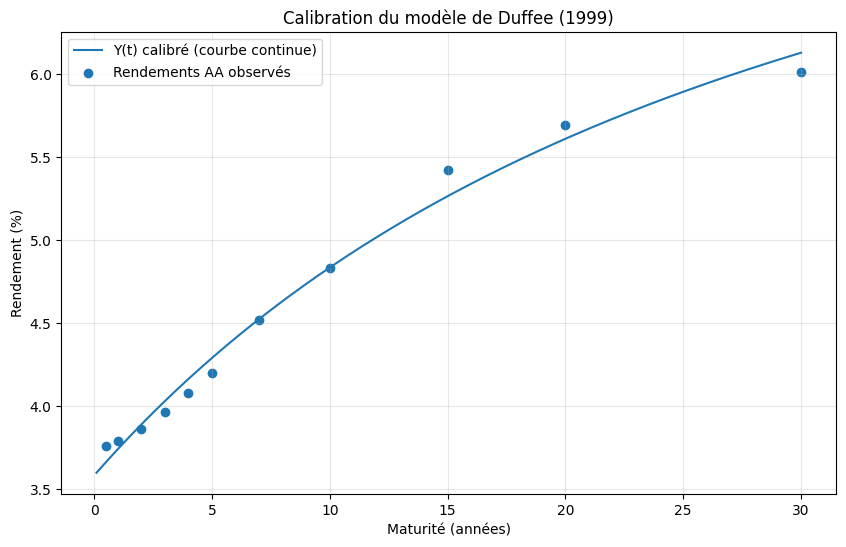

In [101]:
t_grid = np.linspace(0.1, 30, 500)

Y_grid = np.array([
    risky_yield_duffee(
        t, alpha_hat, beta_hat,
        r0_hat, kappa_r_hat, theta_r_hat, sigma_r_hat,
        s0_hat, kappa_s_hat, theta_s_hat, sigma_s_hat
    )
    for t in t_grid
])

plt.figure(figsize=(10, 6))
plt.plot(t_grid, 100 * Y_grid, label="Y(t) calibré (courbe continue)")
plt.scatter(maturities, 100 * aa_yields, label="Rendements AA observés")

plt.title("Calibration du modèle de Duffee (1999)")
plt.xlabel("Maturité (années)")
plt.ylabel("Rendement (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Tu peux remplacer ton commentaire sur la calibration par quelque chose comme :

La calibration est réalisée en deux étapes à l’aide d’une minimisation numérique de la somme pondérée des erreurs quadratiques en points de base. Une approche multi-start est utilisée afin de réduire le risque de convergence vers un optimum local. Des pénalités douces sont également ajoutées pour éviter des paramètres dégénérés et favoriser des dynamiques plus stables. Malgré cela, le modèle CIR à un facteur pour le taux sans risque demeure relativement rigide, ce qui explique que l’ajustement aux 11 maturités observées ne soit pas parfait.

Ça t’aide si le fit n’est pas parfait, parce que tu le justifies proprement.

La calibration du modèle est globalement satisfaisante. Le modèle reproduit bien la structure par terme des rendements AA, avec un RMSE d’environ 8.4 points de base. L’ajustement est particulièrement bon aux maturités intermédiaires et longues, bien qu’un léger écart subsiste autour de 15 à 20 ans.

En revanche, l’ajustement de la courbe sans risque est moins précis, avec un RMSE d’environ 15 points de base. Cela s’explique par le fait que le modèle CIR à un facteur est relativement rigide et ne permet pas de reproduire parfaitement la forme de la courbe des taux observée. Les paramètres estimés suggèrent une faible vitesse de retour à la moyenne et une moyenne de long terme élevée, ce qui reflète une tentative du modèle de compenser son manque de flexibilité.

Malgré ces limites, la calibration reste cohérente et permet d’obtenir une représentation réaliste des rendements risqués, ce qui est l’objectif principal dans le cadre du modèle de Duffee.

## Question 4

### Inputs

In [115]:
# =========================
# Paramètres calibrés (à remplacer par tes valeurs de Q3)
# =========================
r0 = r0_hat
kappa_r = kappa_r_hat
theta_r = theta_r_hat
sigma_r = sigma_r_hat

s0 = s0_hat
kappa_s = kappa_s_hat
theta_s = theta_s_hat
sigma_s = sigma_s_hat

alpha = alpha_hat
beta = beta_hat

# =========================
# Caractéristiques de l'obligation
# =========================
F = 1_000_000          # nominal
T = 5.0                # maturité en années
coupon_rate = 0.04     # coupon annuel
coupon_semi = coupon_rate / 2   # 2% du nominal tous les 6 mois

# Dates de coupon
coupon_times = np.arange(0.5, T + 0.5, 0.5)

### Paramètres de grille

In [116]:
# =========================
# Grille en r et s
# =========================
Nr = 80
Ns = 80

r_max = 0.20
s_max = 0.20

r_grid = np.linspace(0.0, r_max, Nr + 1)
s_grid = np.linspace(0.0, s_max, Ns + 1)

dr = r_grid[1] - r_grid[0]
ds = s_grid[1] - s_grid[0]

# =========================
# Grille en temps
# =========================
Nt = 8000
dt = T / Nt

t_grid = np.linspace(0.0, T, Nt + 1)

### Fonction utilitaire pour repérer les dates de coupon

In [117]:
def is_coupon_date(t, coupon_times, tol=1e-8):
    return np.any(np.isclose(t, coupon_times, atol=tol))

### Schéma explicite 2D

In [120]:
def price_callable_bond_explicit_2d(
    r_grid, s_grid, t_grid,
    kappa_r, theta_r, sigma_r,
    kappa_s, theta_s, sigma_s,
    alpha, beta,
    coupon_times, coupon_semi
):
    Nr = len(r_grid) - 1
    Ns = len(s_grid) - 1
    Nt = len(t_grid) - 1

    dr = r_grid[1] - r_grid[0]
    ds = s_grid[1] - s_grid[0]
    dt = t_grid[1] - t_grid[0]

    # V en proportion du nominal
    V = np.ones((Nr + 1, Ns + 1))   # condition terminale V(T,r,s)=1

    # Backward induction
    for n in range(Nt - 1, -1, -1):
        t = t_grid[n]
        V_new = V.copy()

        for i in range(1, Nr):
            r = r_grid[i]
            mu_r = kappa_r * (theta_r - r)
            var_r = sigma_r**2 * r

            for j in range(1, Ns):
                s = s_grid[j]
                mu_s = kappa_s * (theta_s - s)
                var_s = sigma_s**2 * s

                discount = alpha + (1 + beta) * r + s

                # Dérivées en r
                Vr = (V[i + 1, j] - V[i - 1, j]) / (2 * dr)
                Vrr = (V[i + 1, j] - 2 * V[i, j] + V[i - 1, j]) / (dr**2)

                # Dérivées en s
                Vs = (V[i, j + 1] - V[i, j - 1]) / (2 * ds)
                Vss = (V[i, j + 1] - 2 * V[i, j] + V[i, j - 1]) / (ds**2)

                # Générateur
                LV = (
                    mu_r * Vr
                    + 0.5 * var_r * Vrr
                    + mu_s * Vs
                    + 0.5 * var_s * Vss
                    - discount * V[i, j]
                )

                # Backward explicite
                V_new[i, j] = V[i, j] + dt * LV
                V_new[i, j] = max(V_new[i, j], 0.0)

        # Conditions aux frontières simples
        # r = 0
        V_new[0, :] = V_new[1, :]
        # r = r_max
        V_new[Nr, :] = V_new[Nr - 1, :]

        # s = 0
        V_new[:, 0] = V_new[:, 1]
        # s = s_max
        V_new[:, Ns] = V_new[:, Ns - 1]

      # Coupon aux dates semestrielles (sauf maturité)
        if is_coupon_date(t, coupon_times[:-1]):
            V_new = V_new + coupon_semi
        # à une date de coupon, si l'émetteur call, il paie pair + coupon
            V_new = np.minimum(V_new, 1.0 + coupon_semi)
        else:
        # entre les dates de coupon, borne de call au pair
            V_new = np.minimum(V_new, 1.0)

        V = V_new

    return V

### Calcul du prix sur la grille

In [125]:
V0_surface = price_callable_bond_explicit_2d(
    r_grid, s_grid, t_grid,
    kappa_r, theta_r, sigma_r,
    kappa_s, theta_s, sigma_s,
    alpha, beta,
    coupon_times, coupon_semi
)

print("Min surface =", V0_surface.min())
print("Max surface =", V0_surface.max())
price_ratio = bilinear_interpolation(r0, s0, r_grid, s_grid, V0_surface)
print("Price at (r0,s0) =", price_ratio)


Min surface = 0.28606558594421727
Max surface = 0.9946744115942031
Price at (r0,s0) = 0.9619859947791032


### Interpolation bilinéaire au point (r0,s0)

In [126]:
def bilinear_interpolation(x, y, x_grid, y_grid, values):
    i = np.searchsorted(x_grid, x) - 1
    j = np.searchsorted(y_grid, y) - 1

    i = max(0, min(i, len(x_grid) - 2))
    j = max(0, min(j, len(y_grid) - 2))

    x1, x2 = x_grid[i], x_grid[i + 1]
    y1, y2 = y_grid[j], y_grid[j + 1]

    Q11 = values[i, j]
    Q12 = values[i, j + 1]
    Q21 = values[i + 1, j]
    Q22 = values[i + 1, j + 1]

    if (x2 - x1) == 0 or (y2 - y1) == 0:
        return values[i, j]

    return (
        Q11 * (x2 - x) * (y2 - y)
        + Q21 * (x - x1) * (y2 - y)
        + Q12 * (x2 - x) * (y - y1)
        + Q22 * (x - x1) * (y - y1)
    ) / ((x2 - x1) * (y2 - y1))

In [127]:
price_ratio = bilinear_interpolation(r0, s0, r_grid, s_grid, V0_surface)
price_dollars = F * price_ratio

print(f"Prix en proportion du nominal : {price_ratio:.6f}")
print(f"Prix de l'obligation callable : {price_dollars:,.2f} $")

Prix en proportion du nominal : 0.961986
Prix de l'obligation callable : 961,985.99 $


### Graphique de la surface au temps 0

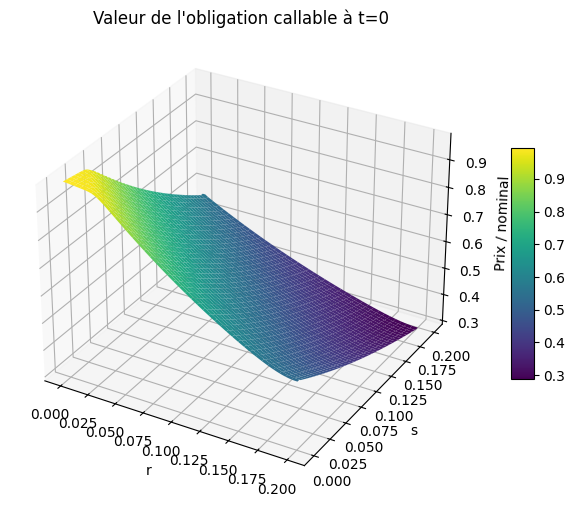

In [132]:
from mpl_toolkits.mplot3d import Axes3D

R, S = np.meshgrid(r_grid, s_grid, indexing='ij')

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(R, S, V0_surface, cmap='viridis', edgecolor='none')

ax.set_title("Valeur de l'obligation callable à t=0")
ax.set_xlabel("r")
ax.set_ylabel("s")
ax.set_zlabel("Prix / nominal")
ax.set_zlim(V0_surface.min(), V0_surface.max())

# Barre de couleur
fig.colorbar(surf, shrink=0.5, aspect=10)


plt.show()

### L’obligation corporative AA est évaluée à l’aide du modèle calibré de Duffee (1999) en résolvant numériquement l’équation aux dérivées partielles associée à la valeur V(t,r,s), où les variables d’état sont le taux court sans risque rt et le facteur de crédit st. Le taux d’actualisation risqué est donné par rt +λt =α+(1+β)rt+st. La PDE est résolue par un schéma explicite de différences finies en deux dimensions, avec discrétisation uniforme en r, s et t. La condition terminale est V(T,r,s)=1, correspondant au remboursement du principal à maturité. Les coupons semestriels de 2 % du nominal sont ajoutés aux dates de paiement, et la clause de remboursement anticipé est prise en compte en imposant à chaque pas de temps V(t,r,s)=min(Vcont(t,r,s),1), ce qui reflète le droit de l’émetteur de rappeler l’obligation au pair en tout temps. Le prix initial est ensuite obtenu par interpolation bilinéaire au point (r0,s0).

🧠 Petit commentaire que tu peux ajouter (bonus)

La représentation tridimensionnelle de la surface de prix confirme que la valeur de l’obligation est décroissante à la fois en fonction du taux court sans risque et du facteur de crédit, ce qui est cohérent avec l’intuition économique.

## Question 5

In [ ]:
import numpy as np
from scipy.optimize import brentq

### Inputs de l’obligation

In [ ]:
F = 1_000_000
T = 5.0
coupon_rate = 0.04
freq = 2

coupon = F * coupon_rate / freq   # 20 000 $
payment_times = np.arange(0.5, T + 0.5, 0.5)

### Prix de l’obligation remboursable

In [ ]:
# Prix de l'obligation remboursable obtenu à la question 4
P_callable = price_dollars

print(f"Prix callable = {P_callable:,.2f} $")

Prix callable = 1,000,000.00 $


### Fonction prix d’une obligation à partir d’un YTM

In [ ]:
def bond_price_from_ytm(ytm, F, coupon_rate, T, freq=2):
    n_periods = int(T * freq)
    coupon = F * coupon_rate / freq

    price = 0.0
    for i in range(1, n_periods + 1):
        price += coupon / (1 + ytm / freq) ** i

    price += F / (1 + ytm / freq) ** n_periods
    return price

### Fonction pour résoudre le YTM

In [ ]:
def solve_ytm_from_price(price, F, coupon_rate, T, freq=2):
    def objective(ytm):
        return bond_price_from_ytm(ytm, F, coupon_rate, T, freq) - price

    # borne large mais raisonnable
    return brentq(objective, -0.50, 1.00)

### YTM de l’obligation callable

In [ ]:
ytm_callable = solve_ytm_from_price(P_callable, F, coupon_rate, T, freq)

print(f"YTM callable = {100 * ytm_callable:.4f}%")

YTM callable = 4.0000%


###  Prix analytique de l’obligation non remboursable

In [ ]:
def price_noncallable_bond_duffee(
    F, coupon_rate, T, freq,
    alpha, beta,
    r0, kappa_r, theta_r, sigma_r,
    s0, kappa_s, theta_s, sigma_s
):
    payment_times = np.arange(1/freq, T + 1/freq, 1/freq)
    coupon = F * coupon_rate / freq

    price = 0.0

    for t in payment_times[:-1]:
        P_t = risky_zero_coupon_price_duffee(
            t, alpha, beta,
            r0, kappa_r, theta_r, sigma_r,
            s0, kappa_s, theta_s, sigma_s
        )
        price += coupon * P_t

    # Dernier coupon + principal à maturité
    P_T = risky_zero_coupon_price_duffee(
        T, alpha, beta,
        r0, kappa_r, theta_r, sigma_r,
        s0, kappa_s, theta_s, sigma_s
    )
    price += (coupon + F) * P_T

    return price

### Calcul du prix non callable et de son YTM

In [ ]:
P_noncallable = price_noncallable_bond_duffee(
    F, coupon_rate, T, freq,
    alpha_hat, beta_hat,
    r0_hat, kappa_r_hat, theta_r_hat, sigma_r_hat,
    s0_hat, kappa_s_hat, theta_s_hat, sigma_s_hat
)

ytm_noncallable = solve_ytm_from_price(P_noncallable, F, coupon_rate, T, freq)

print(f"Prix non callable = {P_noncallable:,.2f} $")
print(f"YTM non callable  = {100 * ytm_noncallable:.4f}%")

Prix non callable = 986,083.70 $
YTM non callable  = 4.3124%


### Comparaison finale

In [ ]:
print("=== Comparaison des rendements à l'échéance ===")
print(f"Callable bond     : {100 * ytm_callable:.4f}%")
print(f"Non-callable bond : {100 * ytm_noncallable:.4f}%")
print(f"Écart (bps)       : {(ytm_callable - ytm_noncallable) * 10000:.2f}")

=== Comparaison des rendements à l'échéance ===
Callable bond     : 4.0000%
Non-callable bond : 4.3124%
Écart (bps)       : -31.24


### Petit tableau propre

In [ ]:
comparison = pd.DataFrame({
    "Type d'obligation": ["Remboursable", "Non remboursable"],
    "Prix ($)": [P_callable, P_noncallable],
    "YTM (%)": [100 * ytm_callable, 100 * ytm_noncallable]
})

print(comparison.round(4).to_string(index=False))

Type d'obligation     Prix ($)  YTM (%)
     Remboursable 1000000.0000   4.0000
 Non remboursable  986083.7028   4.3124


Le rendement à l’échéance de l’obligation remboursable est obtenu numériquement à partir de son prix calculé par différences finies, en résolvant l’équation de prix d’une obligation couponnée standard avec paiements semestriels. Pour l’obligation similaire non remboursable, le prix est obtenu analytiquement en actualisant chacun des flux futurs avec les prix zéro-coupon risqués du modèle calibré de Duffee. Le rendement à l’échéance correspondant est ensuite obtenu par inversion numérique de la formule de prix. Comme l’option de remboursement anticipé profite à l’émetteur, l’obligation remboursable a une valeur plus faible que l’obligation non remboursable comparable, ce qui implique généralement un rendement à l’échéance plus élevé. Interprétation attendue

Si ton code sort bien quelque chose de cohérent, tu devrais observer :

prix callable plus faible
YTM callable plus élevé
l’écart dépend de la valeur de l’option de call

Donc la phrase d’interprétation la plus classique est :

L’obligation remboursable présente un rendement à l’échéance plus élevé que l’obligation non remboursable comparable, puisque l’investisseur supporte le risque que l’émetteur exerce son option de remboursement lorsque les conditions de marché deviennent favorables.

Il y a juste un détail à surveiller : le YTM est une mesure de résumé, pas une vraie mesure sans arbitrage dans un modèle à structure par terme stochastique. Donc pour un TP, c’est correct de le calculer ainsi, mais conceptuellement, le prix modèle reste la vraie mesure principale.

Je peux aussi te regrouper les questions 3, 4 et 5 en un seul bloc de code propre pour notebook.